In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

In [ ]:
import kagglehub

path = kagglehub.dataset_download("aryayadav0513/m5-forecasting-accuracy")
print("Path:", path)

100%|██████████| 45.8M/45.8M [00:00<00:00, 122MB/s]

Extracting files...


Path: /root/.cache/kagglehub/datasets/aryayadav0513/m5-forecasting-accuracy/versions/1


In [ ]:
import os

os.listdir(path)

['m5-forecasting-accuracy']

In [ ]:
import os

os.listdir(path)

['m5-forecasting-accuracy']

In [ ]:
sales = pd.read_csv(f"{path}/m5-forecasting-accuracy/sales_train_validation.csv")
calendar = pd.read_csv(f"{path}/m5-forecasting-accuracy/calendar.csv")
prices = pd.read_csv(f"{path}/m5-forecasting-accuracy/sell_prices.csv")

In [ ]:
import os

dataset_path = os.path.join(path, "m5-forecasting-accuracy")

sales = pd.read_csv(os.path.join(dataset_path, "sales_train_validation.csv"))
calendar = pd.read_csv(os.path.join(dataset_path, "calendar.csv"))
prices = pd.read_csv(os.path.join(dataset_path, "sell_prices.csv"))

In [ ]:
print(sales.shape)
print(calendar.shape)
print(prices.shape)

(30490, 1919)
(1969, 14)
(6841121, 4)


In [ ]:
print(path)
os.listdir(path)

/root/.cache/kagglehub/datasets/aryayadav0513/m5-forecasting-accuracy/versions/1


['m5-forecasting-accuracy']

In [ ]:
sales = pd.read_csv(os.path.join(dataset_path, "sales_train_validation.csv"))
calendar = pd.read_csv(os.path.join(dataset_path, "calendar.csv"))
prices = pd.read_csv(os.path.join(dataset_path, "sell_prices.csv"))

In [ ]:
# FILTER STATE DAN CATEGORY
sales = sales[
    (sales['state_id'].isin(['CA','TX','WI'])) &
    (sales['cat_id'].isin(['HOBBIES','HOUSEHOLD','FOODS']))
]

# AMBIL 50% PRODUCT
sales = sales.sample(frac=0.5, random_state=42)

# AMBIL 50% DAYS
day_cols = [c for c in sales.columns if 'd_' in c]
half_days = day_cols[:len(day_cols)//2]

sales = sales[['item_id','dept_id','cat_id','store_id','state_id'] + half_days]

In [ ]:
sales_long = sales.melt(
    id_vars=['item_id','dept_id','cat_id','store_id','state_id'],
    var_name='d',
    value_name='sales'
)

In [ ]:
sales_long = sales_long.merge(
    calendar[['d','wm_yr_wk']],
    on='d',
    how='left'
)

In [ ]:
sales_long = sales_long.merge(
    prices,
    on=['store_id','item_id','wm_yr_wk'],
    how='left'
)

In [ ]:
sales_long['revenue'] = sales_long['sales'] * sales_long['sell_price']

In [ ]:
weekly_avg = sales_long.groupby(
    ['cat_id','state_id','wm_yr_wk']
)['revenue'].sum().reset_index()

In [ ]:
del sales_long
import gc
gc.collect()

37

In [ ]:
hobbies = weekly_avg[weekly_avg['cat_id']=='HOBBIES']
household = weekly_avg[weekly_avg['cat_id']=='HOUSEHOLD']
foods = weekly_avg[weekly_avg['cat_id']=='FOODS']

In [ ]:
def create_dataset(data, time_step=10):
    X, Y = [], []
    for i in range(len(data)-time_step-1):
        X.append(data[i:(i+time_step)])
        Y.append(data[i+time_step])
    return np.array(X), np.array(Y)

 CATEGORY: HOBBIES 
HOBBIES Revenue Forecast (ARIMA) - CA
MAE   : 786.2082
RMSE  : 979.8089
RMSSE : 1.1040
WRMSEE: 0.0575 (Weight: 0.0521)
MAPE  : 4.10%
------------------------------------------------------------
HOBBIES Revenue Forecast (ARIMA) - TX
MAE   : 527.9140
RMSE  : 665.0543
RMSSE : 1.0493
WRMSEE: 0.0367 (Weight: 0.0350)
MAPE  : 3.99%
------------------------------------------------------------
HOBBIES Revenue Forecast (ARIMA) - WI
MAE   : 489.1383
RMSE  : 665.6369
RMSSE : 0.8611
WRMSEE: 0.0235 (Weight: 0.0273)
MAPE  : 5.23%
------------------------------------------------------------


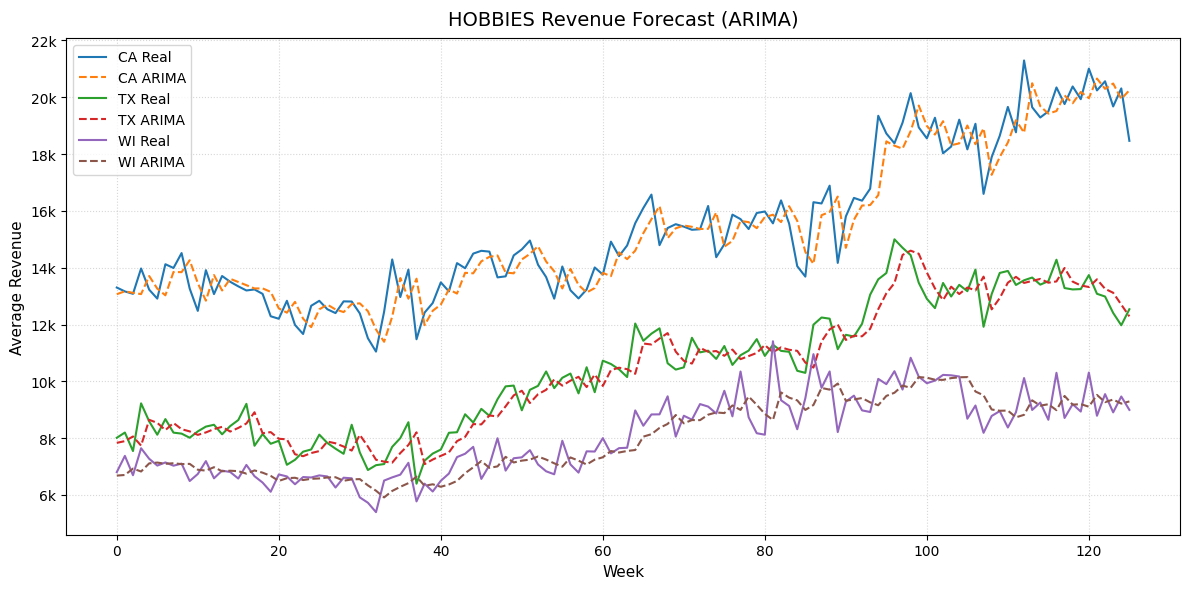

 CATEGORY: HOUSEHOLD 
HOUSEHOLD Revenue Forecast (ARIMA) - CA
MAE   : 1275.0480
RMSE  : 1570.5356
RMSSE : 0.7572
WRMSEE: 0.1012 (Weight: 0.1337)
MAPE  : 2.64%
------------------------------------------------------------
HOUSEHOLD Revenue Forecast (ARIMA) - TX
MAE   : 1013.3053
RMSE  : 1303.4894
RMSSE : 0.8044
WRMSEE: 0.0680 (Weight: 0.0845)
MAPE  : 3.40%
------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


HOUSEHOLD Revenue Forecast (ARIMA) - WI
MAE   : 1567.5230
RMSE  : 1948.5499
RMSSE : 0.9757
WRMSEE: 0.0724 (Weight: 0.0742)
MAPE  : 6.37%
------------------------------------------------------------


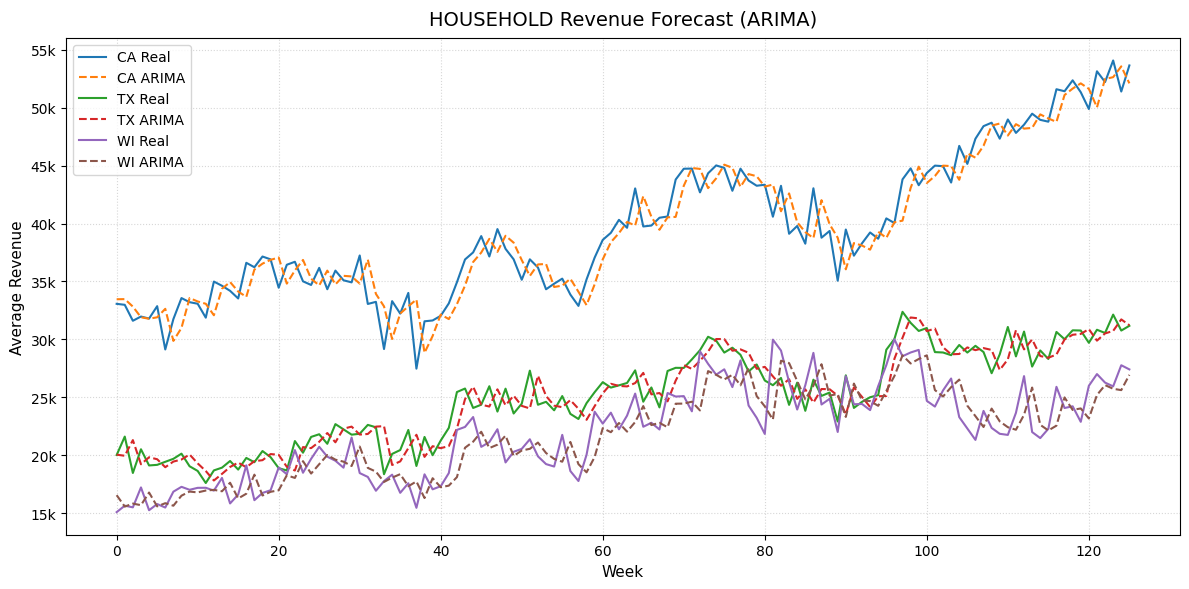

 CATEGORY: FOODS 


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


FOODS Revenue Forecast (ARIMA) - CA
MAE   : 4385.4902
RMSE  : 5884.7244
RMSSE : 0.8124
WRMSEE: 0.2164 (Weight: 0.2663)
MAPE  : 4.88%
------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


FOODS Revenue Forecast (ARIMA) - TX
MAE   : 3234.3853
RMSE  : 3874.0015
RMSSE : 0.7038
WRMSEE: 0.1199 (Weight: 0.1704)
MAPE  : 6.07%
------------------------------------------------------------
FOODS Revenue Forecast (ARIMA) - WI
MAE   : 7814.5834
RMSE  : 8573.9865
RMSSE : 1.1150
WRMSEE: 0.1746 (Weight: 0.1566)
MAPE  : 14.08%
------------------------------------------------------------


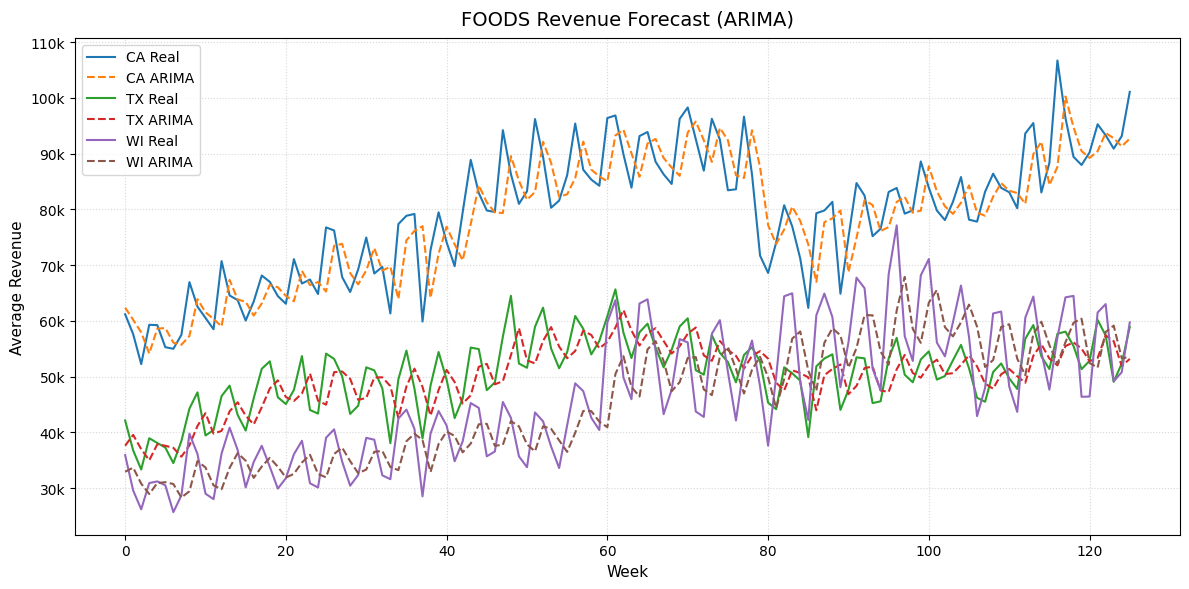

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Helper metrics matching M5 competition standards
def calculate_rmsse(train, test, forecast):
    denominator = np.mean(np.diff(train) ** 2)
    if denominator == 0:
        return 0
    numerator = np.mean((test - forecast) ** 2)
    return np.sqrt(numerator / denominator)

def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# --- FIX: Drop the incomplete final week caused by the 50% day column truncation ---
last_week = weekly_avg['wm_yr_wk'].max()
weekly_avg_filtered = weekly_avg[weekly_avg['wm_yr_wk'] != last_week].copy()

categories = ['HOBBIES', 'HOUSEHOLD', 'FOODS']
states = ['CA', 'TX', 'WI']
test_size = 30
lookback = 10  # Aligns index with RNN lookback window

# 2. Pre-calculate absolute revenue weights for WRMSEE scaling using filtered data
revenue_weights = {}
grand_total_revenue = 0

for cat in categories:
    for state in states:
        df_subset = weekly_avg_filtered[
            (weekly_avg_filtered['cat_id'] == cat) &
            (weekly_avg_filtered['state_id'] == state)
        ]
        if not df_subset.empty:
            total_rev = df_subset['revenue'].sum()
            revenue_weights[(cat, state)] = total_rev
            grand_total_revenue += total_rev

# Plot aesthetics
colors_real = {'CA': 'tab:blue', 'TX': 'tab:green', 'WI': 'tab:purple'}
colors_arima = {'CA': 'tab:orange', 'TX': 'tab:red', 'WI': 'tab:brown'}

# 3. Execution and Visual Alignment Loop
for cat in categories:
    plt.figure(figsize=(12, 6))
    print("=" * 60)
    print(f" CATEGORY: {cat} ")
    print("=" * 60)

    for state in states:
        df_subset = weekly_avg_filtered[
            (weekly_avg_filtered['cat_id'] == cat) &
            (weekly_avg_filtered['state_id'] == state)
        ].sort_values('wm_yr_wk')

        series = df_subset['revenue'].values
        if len(series) == 0:
            continue

        train = series[:-test_size]
        test = series[-test_size:]

        weight = revenue_weights.get((cat, state), 0) / grand_total_revenue

        # Walk-forward tracking
        history = list(train)
        rolling_predictions = []

        for t in range(len(test)):
            model = ARIMA(history, order=(1, 1, 1))
            model_fitted = model.fit()
            yhat = model_fitted.forecast(steps=1)[0]
            rolling_predictions.append(yhat)
            history.append(test[t])

        rolling_predictions = np.array(rolling_predictions)

        # Generate full baseline timeline matching the series shape
        initial_model = ARIMA(train, order=(1, 1, 1)).fit()
        in_sample = initial_model.fittedvalues
        full_pred = np.concatenate([in_sample, rolling_predictions])

        # Metrics computation
        mae = mean_absolute_error(test, rolling_predictions)
        rmse = np.sqrt(mean_squared_error(test, rolling_predictions))
        mape_val = calculate_mape(test, rolling_predictions)
        rmsse = calculate_rmsse(train, test, rolling_predictions)
        wrmsee = weight * rmsse

        # Printed metric summary
        print(f"{cat} Revenue Forecast (ARIMA) - {state}")
        print(f"MAE   : {mae:.4f}")
        print(f"RMSE  : {rmse:.4f}")
        print(f'RMSSE : {rmsse:.4f}')
        print(f"WRMSEE: {wrmsee:.4f} (Weight: {weight:.4f})")
        print(f"MAPE  : {mape_val:.2f}%")
        print("-" * 60)

        # Truncate lookback elements to align perfectly with the RNN's data shape
        plot_real = series[lookback:]
        plot_pred = full_pred[lookback:]

        plt.plot(plot_real, label=f'{state} Real', color=colors_real[state], linestyle='-')
        plt.plot(plot_pred, label=f'{state} ARIMA', color=colors_arima[state], linestyle='--')

    # Chart polish
    plt.title(f"{cat} Revenue Forecast (ARIMA)", fontsize=14, pad=10)
    plt.xlabel("Week", fontsize=11)
    plt.ylabel("Average Revenue", fontsize=11)

    ax = plt.gca()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}k' if x >= 1000 else f'{int(x)}'))

    plt.legend(loc='upper left', frameon=True)
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()

 CATEGORY: HOBBIES 
HOBBIES - CA (Selected Order: ARIMA(0, 1, 2))
MAE   : 784.8545
RMSE  : 986.9503
WRMSSE: 0.0579 (Weight: 0.0521)
MAPE  : 4.10%
------------------------------------------------------------
HOBBIES - TX (Selected Order: ARIMA(0, 1, 1))
MAE   : 525.7200
RMSE  : 662.5007
WRMSSE: 0.0365 (Weight: 0.0350)
MAPE  : 3.97%
------------------------------------------------------------
HOBBIES - WI (Selected Order: ARIMA(2, 1, 2))
MAE   : 504.0879
RMSE  : 705.4924
WRMSSE: 0.0249 (Weight: 0.0273)
MAPE  : 5.34%
------------------------------------------------------------


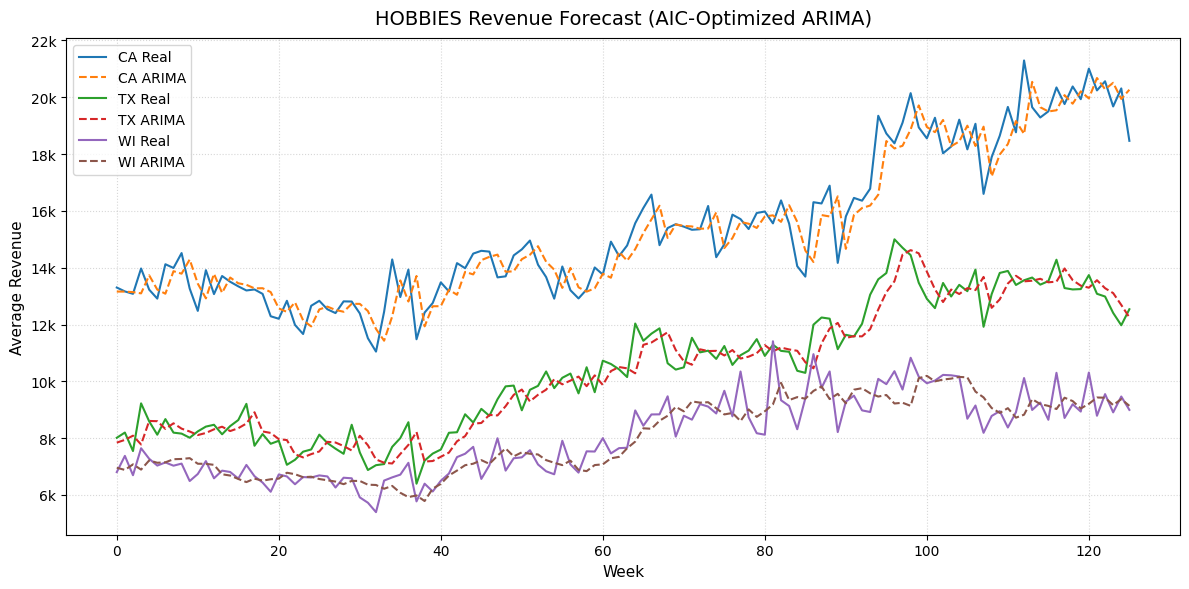

 CATEGORY: HOUSEHOLD 
HOUSEHOLD - CA (Selected Order: ARIMA(2, 1, 0))
MAE   : 1272.7781
RMSE  : 1569.4507
WRMSSE: 0.1012 (Weight: 0.1337)
MAPE  : 2.64%
------------------------------------------------------------
HOUSEHOLD - TX (Selected Order: ARIMA(1, 1, 2))
MAE   : 1019.7283
RMSE  : 1291.4081
WRMSSE: 0.0673 (Weight: 0.0845)
MAPE  : 3.43%
------------------------------------------------------------
HOUSEHOLD - WI (Selected Order: ARIMA(1, 1, 1))
MAE   : 1567.5230
RMSE  : 1948.5499
WRMSSE: 0.0724 (Weight: 0.0742)
MAPE  : 6.37%
------------------------------------------------------------


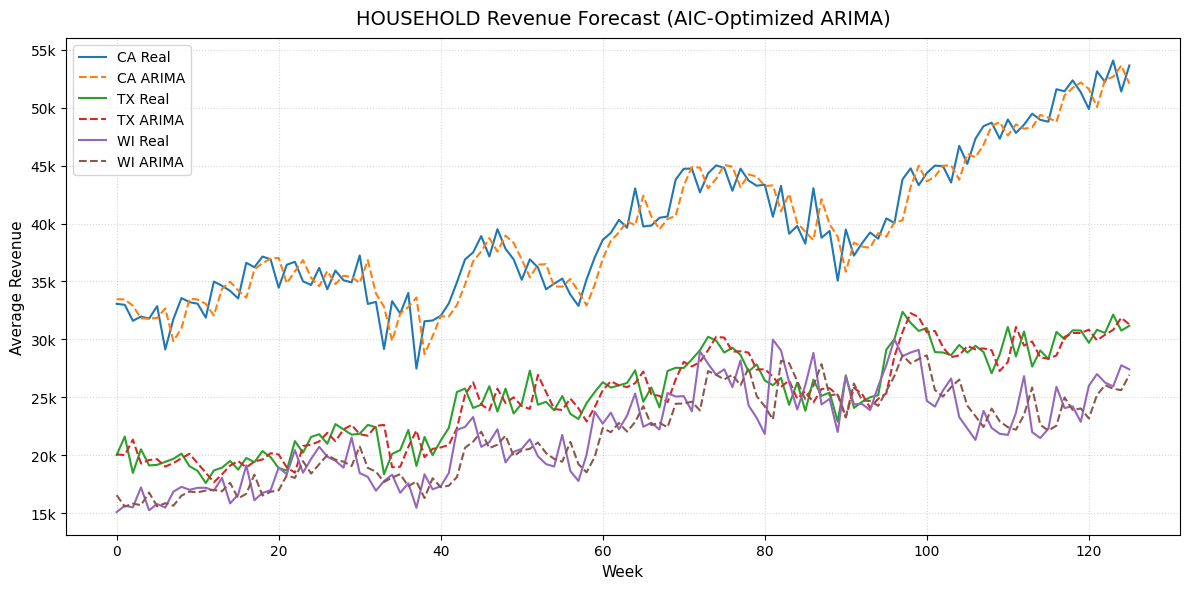

 CATEGORY: FOODS 
FOODS - CA (Selected Order: ARIMA(2, 1, 2))
MAE   : 3860.1002
RMSE  : 5240.1485
WRMSSE: 0.1927 (Weight: 0.2663)
MAPE  : 4.35%
------------------------------------------------------------
FOODS - TX (Selected Order: ARIMA(2, 1, 2))
MAE   : 2358.0893
RMSE  : 2900.4492
WRMSSE: 0.0898 (Weight: 0.1704)
MAPE  : 4.38%
------------------------------------------------------------
FOODS - WI (Selected Order: ARIMA(2, 1, 2))
MAE   : 3548.5503
RMSE  : 4314.6495
WRMSSE: 0.0879 (Weight: 0.1566)
MAPE  : 6.22%
------------------------------------------------------------


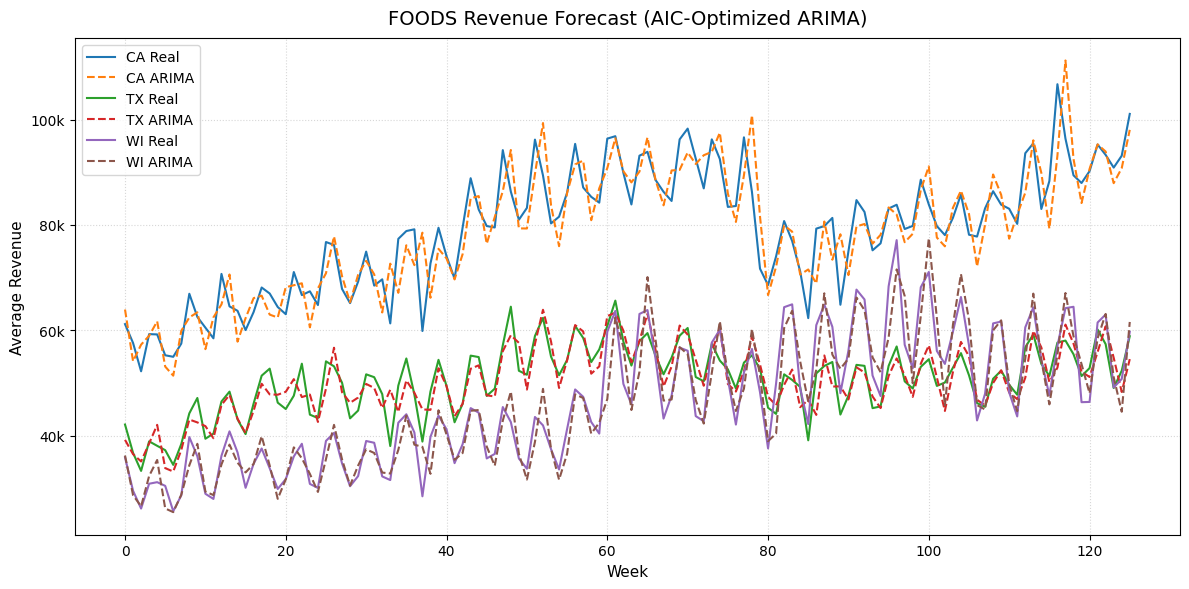

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Suppress convergence warnings from non-matching grid search orders
warnings.filterwarnings("ignore")

# 1. Helper metrics matching M5 competition standards
def calculate_rmsse(train, test, forecast):
    denominator = np.mean(np.diff(train) ** 2)
    if denominator == 0:
        return 0
    numerator = np.mean((test - forecast) ** 2)
    return np.sqrt(numerator / denominator)

def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# 2. Anti-Overfitting Hyperparameter Optimization Engine
def find_best_arima_order(train_series):
    """
    Finds the optimal (p, d, q) order using AIC to minimize overfitting risks.
    We cap orders at 2 to keep the model parsimonious and stable.
    """
    best_aic = float('inf')
    best_order = (1, 1, 1)  # Robust default fallback

    for p in [0, 1, 2]:
        for d in [0, 1]:
            for q in [0, 1, 2]:
                try:
                    model = ARIMA(train_series, order=(p, d, q))
                    results = model.fit()
                    if results.aic < best_aic:
                        best_aic = results.aic
                        best_order = (p, d, q)
                except:
                    continue
    return best_order

# --- Drop the incomplete final boundary week ---
last_week = weekly_avg['wm_yr_wk'].max()
weekly_avg_filtered = weekly_avg[weekly_avg['wm_yr_wk'] != last_week].copy()

categories = ['HOBBIES', 'HOUSEHOLD', 'FOODS']
states = ['CA', 'TX', 'WI']
test_size = 30
lookback = 10  # Aligns index with your RNN lookback window

# 3. Pre-calculate absolute revenue weights for WRMSEE scaling
revenue_weights = {}
grand_total_revenue = 0

for cat in categories:
    for state in states:
        df_subset = weekly_avg_filtered[
            (weekly_avg_filtered['cat_id'] == cat) &
            (weekly_avg_filtered['state_id'] == state)
        ]
        if not df_subset.empty:
            total_rev = df_subset['revenue'].sum()
            revenue_weights[(cat, state)] = total_rev
            grand_total_revenue += total_rev

# Plot aesthetics
colors_real = {'CA': 'tab:blue', 'TX': 'tab:green', 'WI': 'tab:purple'}
colors_arima = {'CA': 'tab:orange', 'TX': 'tab:red', 'WI': 'tab:brown'}

# 4. Execution and Visual Alignment Loop
for cat in categories:
    plt.figure(figsize=(12, 6))
    print("=" * 60)
    print(f" CATEGORY: {cat} ")
    print("=" * 60)

    for state in states:
        df_subset = weekly_avg_filtered[
            (weekly_avg_filtered['cat_id'] == cat) &
            (weekly_avg_filtered['state_id'] == state)
        ].sort_values('wm_yr_wk')

        series = df_subset['revenue'].values
        if len(series) == 0:
            continue

        train = series[:-test_size]
        test = series[-test_size:]

        weight = revenue_weights.get((cat, state), 0) / grand_total_revenue

        # Find the optimal order on training data to prevent overfitting
        best_order = find_best_arima_order(train)

        # Walk-forward tracking using the optimal parsimonious order
        history = list(train)
        rolling_predictions = []

        for t in range(len(test)):
            model = ARIMA(history, order=best_order)
            model_fitted = model.fit()
            yhat = model_fitted.forecast(steps=1)[0]
            rolling_predictions.append(yhat)
            history.append(test[t])

        rolling_predictions = np.array(rolling_predictions)

        # Generate full baseline timeline matching the series shape
        initial_model = ARIMA(train, order=best_order).fit()
        in_sample = initial_model.fittedvalues
        full_pred = np.concatenate([in_sample, rolling_predictions])

        # Metrics computation
        mae = mean_absolute_error(test, rolling_predictions)
        rmse = np.sqrt(mean_squared_error(test, rolling_predictions))
        mape_val = calculate_mape(test, rolling_predictions)
        rmsse = calculate_rmsse(train, test, rolling_predictions)
        wrmsee = weight * rmsse

        # Printed metric summary
        print(f"{cat} - {state} (Selected Order: ARIMA{best_order})")
        print(f"MAE   : {mae:.4f}")
        print(f"RMSE  : {rmse:.4f}")
        print(f"WRMSSE: {wrmsee:.4f} (Weight: {weight:.4f})")
        print(f"MAPE  : {mape_val:.2f}%")
        print("-" * 60)

        # Truncate lookback elements to align perfectly with the RNN's data shape
        plot_real = series[lookback:]
        plot_pred = full_pred[lookback:]

        plt.plot(plot_real, label=f'{state} Real', color=colors_real[state], linestyle='-')
        plt.plot(plot_pred, label=f'{state} ARIMA', color=colors_arima[state], linestyle='--')

    # Chart polish
    plt.title(f"{cat} Revenue Forecast (AIC-Optimized ARIMA)", fontsize=14, pad=10)
    plt.xlabel("Week", fontsize=11)
    plt.ylabel("Average Revenue", fontsize=11)

    ax = plt.gca()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}k' if x >= 1000 else f'{int(x)}'))

    plt.legend(loc='upper left', frameon=True)
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [ ]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.2 MB/s eta 0:00:00


### CNN Revenue Forecast

This section was referenced by the notebook's imports (Keras `Sequential`/`LSTM`/`Dense`, the `create_dataset` windowing helper, and the `keras-tuner` install) but the actual model code was missing. Added here: a small Conv1D model, tuned globally with Keras Tuner on shuffled windows pooled across all category/state series (avoiding the same tail-slice validation bias fixed in the LightGBM section below), then refit per series and evaluated with the same walk-forward strategy and metrics (MAE, RMSE, RMSSE, WRMSEE, MAPE) used elsewhere in the notebook.

In [ ]:
import gc
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt

# ==========================================================
# METRICS (identical to the ARIMA / LightGBM sections)
# ==========================================================

def calculate_rmsse(train, test, forecast):
    train = np.array(train).flatten()
    test = np.array(test).flatten()
    forecast = np.array(forecast).flatten()

    denominator = np.mean(np.diff(train) ** 2)
    if denominator < 1e-8:
        return np.nan

    numerator = np.mean((test - forecast) ** 2)
    return np.sqrt(numerator / denominator)


def calculate_mape(y_true, y_pred):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    mask = y_true != 0
    if np.sum(mask) == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


# ==========================================================
# WINDOWING
# ==========================================================

time_step = lookback  # same 10-week lookback used in the ARIMA / LightGBM sections


def make_windows(series_scaled, time_step):
    X, y = [], []
    for i in range(len(series_scaled) - time_step):
        X.append(series_scaled[i:i + time_step])
        y.append(series_scaled[i + time_step])
    return np.array(X), np.array(y)


# ==========================================================
# GLOBAL DATASET FOR HYPERPARAMETER SEARCH
#
# NOTE: each series gets its own MinMaxScaler (fit on that series'
# training data only), and every series contributes windows to the
# tuning set. This avoids the same bias we fixed in the LightGBM
# section, where naively slicing the tail of a concatenated dataframe
# for validation ended up drawing from only the last series appended.
# ==========================================================

print("Preparing global tuning dataset...")

tuning_X, tuning_y = [], []
series_scalers = {}  # fitted per (cat, state), reused during per-series fitting below

for cat in categories:
    for state in states:
        df_subset = weekly_avg_filtered[
            (weekly_avg_filtered["cat_id"] == cat) &
            (weekly_avg_filtered["state_id"] == state)
        ].sort_values("wm_yr_wk")

        series = df_subset["revenue"].values.astype(float)
        if len(series) < time_step + test_size + 1:
            continue

        train_series = series[:-test_size]

        scaler = MinMaxScaler()
        train_scaled = scaler.fit_transform(train_series.reshape(-1, 1)).flatten()
        series_scalers[(cat, state)] = scaler

        Xs, ys = make_windows(train_scaled, time_step)
        if len(Xs) == 0:
            continue
        tuning_X.append(Xs)
        tuning_y.append(ys)

tuning_X = np.concatenate(tuning_X, axis=0)
tuning_y = np.concatenate(tuning_y, axis=0)

# Shuffle before splitting so the validation slice draws from every
# series instead of whichever one happens to be appended last.
rng = np.random.default_rng(42)
perm = rng.permutation(len(tuning_X))
tuning_X, tuning_y = tuning_X[perm], tuning_y[perm]

tuning_X = tuning_X.reshape(tuning_X.shape[0], tuning_X.shape[1], 1)

val_size = int(0.2 * len(tuning_X))
X_train_tune, X_val_tune = tuning_X[:-val_size], tuning_X[-val_size:]
y_train_tune, y_val_tune = tuning_y[:-val_size], tuning_y[-val_size:]

# ==========================================================
# KERAS TUNER SEARCH (small Conv1D architecture, kept shallow
# on purpose since each series only has a few dozen training rows)
# ==========================================================

def build_model(hp):
    model = Sequential()
    model.add(Input(shape=(time_step, 1)))
    model.add(Conv1D(
        filters=hp.Choice("filters", [16, 32, 64]),
        kernel_size=hp.Choice("kernel_size", [2, 3]),
        activation="relu",
        padding="causal",
    ))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Flatten())
    model.add(Dense(hp.Choice("dense_units", [16, 32, 64]), activation="relu"))
    model.add(Dense(1))
    model.compile(optimizer="adam", loss="mse")
    return model


tuner = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=10,
    executions_per_trial=1,
    overwrite=True,
    directory="cnn_tuner_dir",
    project_name="revenue_cnn",
)

early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

print("Running CNN hyperparameter search...")
tuner.search(
    X_train_tune, y_train_tune,
    validation_data=(X_val_tune, y_val_tune),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print("\nBest Hyperparameters")
print(best_hp.values)

val_model = build_model(best_hp)
val_model.fit(
    X_train_tune, y_train_tune,
    epochs=30, batch_size=32,
    callbacks=[early_stop],
    verbose=0,
)
val_pred = val_model.predict(X_val_tune, verbose=0).flatten()
val_rmse = np.sqrt(np.mean((val_pred - y_val_tune) ** 2))
print(f"Validation RMSE (scaled features, global fit): {val_rmse:.4f}")


In [ ]:
# ==========================================================
# PARAMETERS FOR PER-SERIES PLOTS
# ==========================================================

colors_real = {"CA": "tab:blue", "TX": "tab:green", "WI": "tab:purple"}
colors_cnn = {"CA": "tab:orange", "TX": "tab:red", "WI": "tab:brown"}

all_wrmsee_cnn = []

# ==========================================================
# PER-SERIES FIT + WALK-FORWARD FORECAST
# (same walk-forward strategy as the ARIMA / LightGBM sections:
#  predict one week, then append the *actual* observed value to
#  history before building the next window)
# ==========================================================

for cat in categories:
    plt.figure(figsize=(12, 6))
    print("=" * 60)
    print(f"CATEGORY : {cat}")
    print("=" * 60)

    for state in states:
        key = (cat, state)
        if key not in series_scalers:
            continue

        df_subset = weekly_avg_filtered[
            (weekly_avg_filtered["cat_id"] == cat) &
            (weekly_avg_filtered["state_id"] == state)
        ].sort_values("wm_yr_wk")

        series = df_subset["revenue"].values.astype(float)
        train_data = series[:-test_size]
        test_data = series[-test_size:]

        scaler = series_scalers[key]
        train_scaled = scaler.transform(train_data.reshape(-1, 1)).flatten()

        X_train, y_train = make_windows(train_scaled, time_step)
        X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)

        model = build_model(best_hp)
        model.fit(
            X_train, y_train,
            epochs=30,
            batch_size=32,
            callbacks=[EarlyStopping(monitor="loss", patience=3, restore_best_weights=True)],
            verbose=0,
        )

        # ==========================================
        # WALK-FORWARD PREDICTION
        # ==========================================

        history_scaled = list(train_scaled)
        predictions_scaled = []

        for i in range(len(test_data)):
            window = np.array(history_scaled[-time_step:]).reshape(1, time_step, 1)
            pred_scaled = model.predict(window, verbose=0)[0, 0]
            predictions_scaled.append(pred_scaled)

            # walk-forward: append the actual observed value, not the prediction
            actual_scaled = scaler.transform([[test_data[i]]])[0, 0]
            history_scaled.append(actual_scaled)

        predictions = scaler.inverse_transform(
            np.array(predictions_scaled).reshape(-1, 1)
        ).flatten()
        actual = test_data

        # ==========================================
        # METRICS
        # ==========================================

        mae = mean_absolute_error(actual, predictions)
        rmse = np.sqrt(mean_squared_error(actual, predictions))
        mape = calculate_mape(actual, predictions)
        rmsse = calculate_rmsse(train_data, actual, predictions)

        weight = revenue_weights[(cat, state)] / grand_total_revenue
        wrmsee = weight * rmsse
        all_wrmsee_cnn.append(wrmsee)

        print(f"{cat}-{state}")
        print(f"MAE    : {mae:.4f}")
        print(f"RMSE   : {rmse:.4f}")
        print(f"RMSSE  : {rmsse:.4f}")
        print(f"WRMSEE : {wrmsee:.4f} (Cumulative: {np.nansum(all_wrmsee_cnn):.4f})")
        print(f"MAPE   : {mape:.2f}%")
        print("-" * 50)

        # ==========================================
        # TRAIN FIT FOR PLOT
        # ==========================================

        train_pred_scaled = model.predict(X_train, verbose=0).flatten()
        train_pred = scaler.inverse_transform(train_pred_scaled.reshape(-1, 1)).flatten()

        full_pred = np.empty(len(series))
        full_pred[:] = np.nan
        full_pred[time_step: time_step + len(train_pred)] = train_pred
        full_pred[len(series) - len(predictions):] = predictions

        plt.plot(series[time_step:], label=f"{state} Real", color=colors_real[state])
        plt.plot(full_pred[time_step:], "--", label=f"{state} CNN", color=colors_cnn[state])

    plt.title(f"{cat} Revenue Forecast (CNN)")
    plt.xlabel("Week")
    plt.ylabel("Revenue")

    ax = plt.gca()
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, pos: f"{int(x/1000)}k" if x >= 1000 else f"{int(x)}")
    )

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    gc.collect()

# ==========================================================
# OVERALL WRMSEE
# ==========================================================

print("\n" + "#" * 60)
print(f"Overall WRMSEE : {np.nansum(all_wrmsee_cnn):.4f}")
print("#" * 60)


### LightGBM Revenue Forecast

This section implements a **LightGBM** gradient-boosted-tree model as an alternative to the ARIMA/LSTM/CNN forecasts above.

Unlike the CNN/LSTM models, LightGBM operates on **tabular features** rather than raw sequences, so each week is converted into a row containing:

- `lag_1 ... lag_10`: revenue from the previous 10 weeks
- `roll_mean_w` / `roll_std_w`: rolling mean/std over 3, 5, and 10-week windows
- `week_idx`: a simple trend index

**Key steps:**
1. **Feature engineering** — convert each category/state revenue series into a lagged tabular dataset.
2. **Hyperparameter search** — a global `RandomizedSearchCV` over LightGBM parameters (num_leaves, depth, learning rate, etc.), analogous to the Keras Tuner step used for the CNN.
3. **Per-series fit** — refit LightGBM with the best hyperparameters for each category/state pair.
4. **Walk-forward prediction** — predict one week at a time, then append the *actual* observed test value to history before building next week's features (same strategy as the CNN/LSTM sections).
5. **Metrics** — MAE, RMSE, RMSSE, WRMSEE, and MAPE, computed with the same helper functions used elsewhere in the notebook.
6. **Visualization** — real vs. LightGBM-forecast weekly revenue per category and state.

Install once if needed: `!pip install lightgbm`

In [ ]:
!pip install lightgbm

In [ ]:
import warnings
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
import lightgbm as lgb

warnings.filterwarnings("ignore")

# ==========================================================
# METRICS (identical to the ARIMA / CNN sections)
# ==========================================================

def calculate_rmsse(train, test, forecast):
    train = np.array(train).flatten()
    test = np.array(test).flatten()
    forecast = np.array(forecast).flatten()

    denominator = np.mean(np.diff(train) ** 2)
    if denominator < 1e-8:
        return np.nan

    numerator = np.mean((test - forecast) ** 2)
    return np.sqrt(numerator / denominator)


def calculate_mape(y_true, y_pred):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    mask = y_true != 0
    if np.sum(mask) == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


# ==========================================================
# FEATURE ENGINEERING
# ==========================================================

time_step = 10          # same lookback window used for the CNN/LSTM models
n_lags = time_step       # number of lag features
roll_windows = [3, 5, 10]  # rolling mean/std windows (must be <= n_lags)


def build_feature_frame(series: np.ndarray, n_lags: int, roll_windows) -> pd.DataFrame:
    """
    Turns a 1D revenue series into a tabular feature set:
      lag_1 ... lag_n         -> previous n weeks
      roll_mean_w / roll_std_w -> rolling stats over lag_1..lag_w
      week_idx                 -> simple trend index
    Target column 'y' is the current week's revenue.
    """
    df = pd.DataFrame({"y": series})

    for lag in range(1, n_lags + 1):
        df[f"lag_{lag}"] = df["y"].shift(lag)

    for w in roll_windows:
        lag_cols = [f"lag_{i}" for i in range(1, w + 1)]
        df[f"roll_mean_{w}"] = df[lag_cols].mean(axis=1)
        df[f"roll_std_{w}"] = df[lag_cols].std(axis=1)

    df["week_idx"] = np.arange(len(df))

    df = df.dropna().reset_index(drop=True)
    feature_cols = [c for c in df.columns if c != "y"]
    return df, feature_cols


# ==========================================================
# GLOBAL DATASET FOR HYPERPARAMETER SEARCH
# ==========================================================

print("Preparing global tuning dataset...")

# NOTE: previously this concatenated every series' feature frame in
# order (HOBBIES-CA, HOBBIES-TX, ..., FOODS-WI) and then took the tail
# 20% as the validation set. Since each series was appended as one
# contiguous block, that tail slice ended up drawing almost entirely
# from the last series (FOODS-WI) rather than being representative of
# all category/state combinations, which biased the hyperparameter
# search. Fix: take the tail 20% of EACH series individually for
# validation, so every series contributes to both train and val.
global_train_frames = []
global_val_frames = []

for cat in categories:
    for state in states:
        df_subset = weekly_avg_filtered[
            (weekly_avg_filtered["cat_id"] == cat) &
            (weekly_avg_filtered["state_id"] == state)
        ].sort_values("wm_yr_wk")

        series = df_subset["revenue"].values
        if len(series) < n_lags + test_size + 1:
            continue

        train_series = series[:-test_size]
        feat_df, feature_cols = build_feature_frame(train_series, n_lags, roll_windows)
        feat_df["cat_id"] = cat
        feat_df["state_id"] = state

        if len(feat_df) < 5:
            continue

        val_len = max(1, int(0.2 * len(feat_df)))
        global_train_frames.append(feat_df.iloc[:-val_len])
        global_val_frames.append(feat_df.iloc[-val_len:])

train_tune = pd.concat(global_train_frames, ignore_index=True)
val_tune = pd.concat(global_val_frames, ignore_index=True)
feature_cols = [c for c in train_tune.columns if c not in ("y", "cat_id", "state_id")]

X_train_tune = train_tune[feature_cols]
y_train_tune = train_tune["y"]
X_val_tune = val_tune[feature_cols]
y_val_tune = val_tune["y"]

# ==========================================================
# HYPERPARAMETER SEARCH (RandomizedSearchCV)
# ==========================================================

print("Running LightGBM hyperparameter search...")

param_dist = {
    "num_leaves": [15, 31, 63, 127],
    "max_depth": [-1, 4, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "n_estimators": [200, 400, 600, 800],
    "min_child_samples": [5, 10, 20, 30],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0.0, 0.1, 0.5],
    "reg_lambda": [0.0, 0.1, 0.5],
}

base_model = lgb.LGBMRegressor(objective="regression", random_state=42, verbosity=-1)

search = RandomizedSearchCV(
    base_model,
    param_distributions=param_dist,
    n_iter=25,
    scoring="neg_mean_squared_error",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=0,
)

search.fit(X_train_tune, y_train_tune)
best_params = search.best_params_

print("\nBest Hyperparameters")
print(best_params)

val_pred = search.best_estimator_.predict(X_val_tune)
val_rmse = np.sqrt(mean_squared_error(y_val_tune, val_pred))
print(f"Validation RMSE (scaled features, global fit): {val_rmse:.4f}")

# ==========================================================
# PARAMETERS FOR PER-SERIES PLOTS
# ==========================================================

colors_real = {"CA": "tab:blue", "TX": "tab:green", "WI": "tab:purple"}
colors_lgbm = {"CA": "tab:orange", "TX": "tab:red", "WI": "tab:brown"}

all_wrmsee_lgbm = []

# ==========================================================
# FORECASTING LOOP
# ==========================================================

for cat in categories:
    plt.figure(figsize=(12, 6))

    print("=" * 60)
    print(f"CATEGORY : {cat}")
    print("=" * 60)

    for state in states:
        df_subset = weekly_avg_filtered[
            (weekly_avg_filtered["cat_id"] == cat) &
            (weekly_avg_filtered["state_id"] == state)
        ].sort_values("wm_yr_wk")

        series = df_subset["revenue"].values
        if len(series) < n_lags + test_size + 1:
            continue

        # ==========================================
        # TRAIN / TEST SPLIT
        # ==========================================

        train_data = series[:-test_size]
        test_data = series[-test_size:]

        train_feat_df, feature_cols = build_feature_frame(train_data, n_lags, roll_windows)
        X_train = train_feat_df[feature_cols]
        y_train = train_feat_df["y"]

        # ==========================================
        # FIT MODEL WITH BEST HYPERPARAMETERS
        # ==========================================

        model = lgb.LGBMRegressor(
            objective="regression",
            random_state=42,
            verbosity=-1,
            **best_params,
        )
        model.fit(X_train, y_train)

        # ==========================================
        # WALK-FORWARD PREDICTION
        # ==========================================

        history = list(train_data)
        predictions = []

        for i in range(len(test_data)):
            hist_arr = np.array(history)
            feat_row = {}

            for lag in range(1, n_lags + 1):
                feat_row[f"lag_{lag}"] = hist_arr[-lag]

            for w in roll_windows:
                lag_vals = hist_arr[-w:]
                feat_row[f"roll_mean_{w}"] = np.mean(lag_vals)
                feat_row[f"roll_std_{w}"] = np.std(lag_vals)

            feat_row["week_idx"] = len(hist_arr)

            X_input = pd.DataFrame([feat_row])[feature_cols]
            pred = model.predict(X_input)[0]
            predictions.append(pred)

            # walk-forward: append the actual observed value, not the prediction
            history.append(test_data[i])

        predictions = np.array(predictions)
        actual = test_data

        # ==========================================
        # METRICS
        # ==========================================

        mae = mean_absolute_error(actual, predictions)
        rmse = np.sqrt(mean_squared_error(actual, predictions))
        mape = calculate_mape(actual, predictions)
        rmsse = calculate_rmsse(train_data, actual, predictions)

        weight = revenue_weights[(cat, state)] / grand_total_revenue
        wrmsee = weight * rmsse
        all_wrmsee_lgbm.append(wrmsee)

        print(f"{cat}-{state}")
        print(f"MAE    : {mae:.4f}")
        print(f"RMSE   : {rmse:.4f}")
        print(f"RMSSE  : {rmsse:.4f}")
        print(f"WRMSEE : {wrmsee:.4f} (Cumulative: {np.nansum(all_wrmsee_lgbm):.4f})")
        print(f"MAPE   : {mape:.2f}%")
        print("-" * 50)

        # ==========================================
        # TRAIN FIT FOR PLOT
        # ==========================================

        train_pred = model.predict(X_train)

        full_pred = np.empty(len(series))
        full_pred[:] = np.nan
        full_pred[n_lags: n_lags + len(train_pred)] = train_pred
        full_pred[len(series) - len(predictions):] = predictions

        plt.plot(series[n_lags:], label=f"{state} Real", color=colors_real[state])
        plt.plot(full_pred[n_lags:], "--", label=f"{state} LightGBM", color=colors_lgbm[state])

    plt.title(f"{cat} Revenue Forecast (LightGBM)")
    plt.xlabel("Week")
    plt.ylabel("Revenue")

    ax = plt.gca()
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, pos: f"{int(x/1000)}k" if x >= 1000 else f"{int(x)}")
    )

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    gc.collect()

# ==========================================================
# OVERALL WRMSEE
# ==========================================================

print("\n" + "#" * 60)
print(f"Overall WRMSEE : {np.nansum(all_wrmsee_lgbm):.4f}")
print("#" * 60)